In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Load data
df = pd.read_csv(r'superstore_sales.csv', encoding='latin1')

In [6]:
# Data preparation
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year-Month'] = df['Order Date'].dt.to_period('M')

In [7]:
# 1. Monthly Revenue Trends
monthly_revenue = df.groupby('Year-Month')['Sales'].sum().reset_index()
monthly_revenue['Year-Month'] = monthly_revenue['Year-Month'].astype(str)

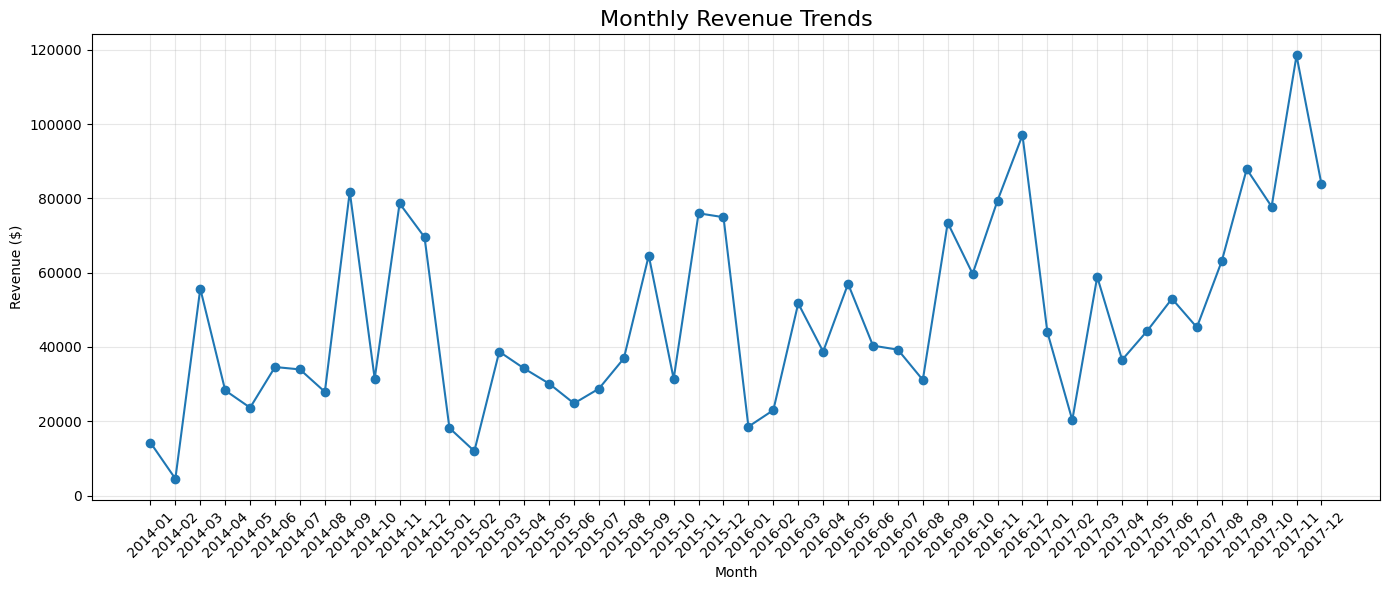

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['Year-Month'], monthly_revenue['Sales'], marker='o')
plt.title('Monthly Revenue Trends', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue_trends.png', dpi=300)
plt.show()

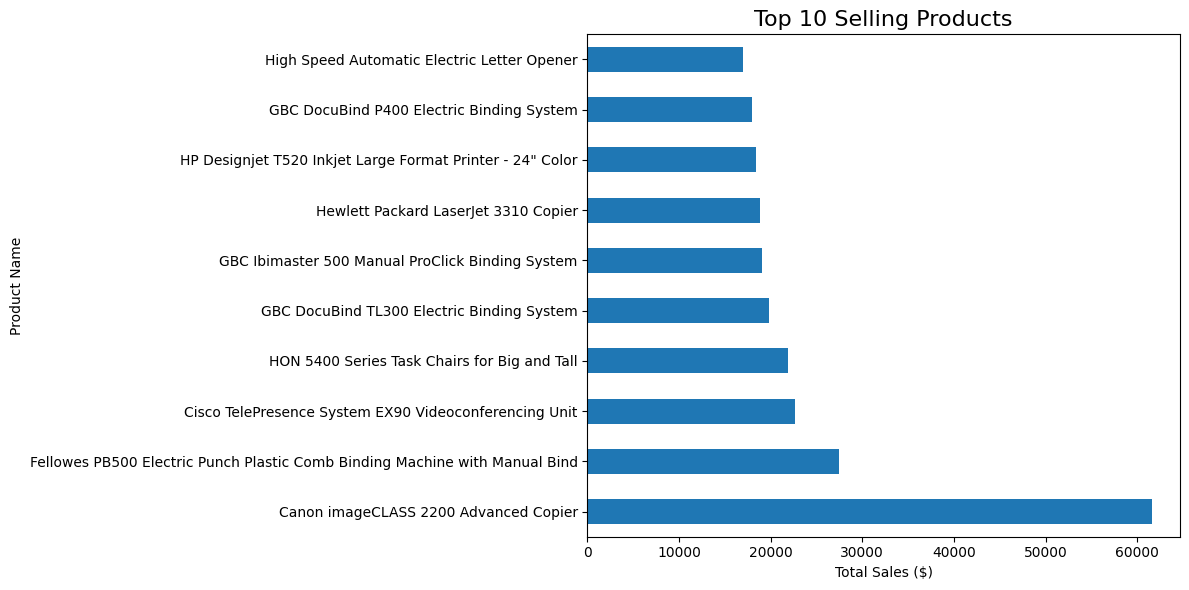

In [9]:
# 2. Top-Selling Products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind='barh')
plt.title('Top 10 Selling Products', fontsize=16)
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('top_selling_products.png', dpi=300)
plt.show()

In [10]:
# 3. Profit Analysis
# Overall profit margin
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# Profit by category
profit_by_category = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit Margin': 'mean'
}).round(2)

print("\n=== PROFIT ANALYSIS BY CATEGORY ===")
print(profit_by_category)


=== PROFIT ANALYSIS BY CATEGORY ===
                     Sales     Profit  Profit Margin
Category                                            
Furniture        741999.80   18451.27           3.88
Office Supplies  719047.03  122490.80          13.80
Technology       836154.03  145454.95          15.61


<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_2881/1534444343.py:6: SyntaxWarning: invalid escape sequence '\$'
  axes[0].set_ylabel('Profit (\$)')


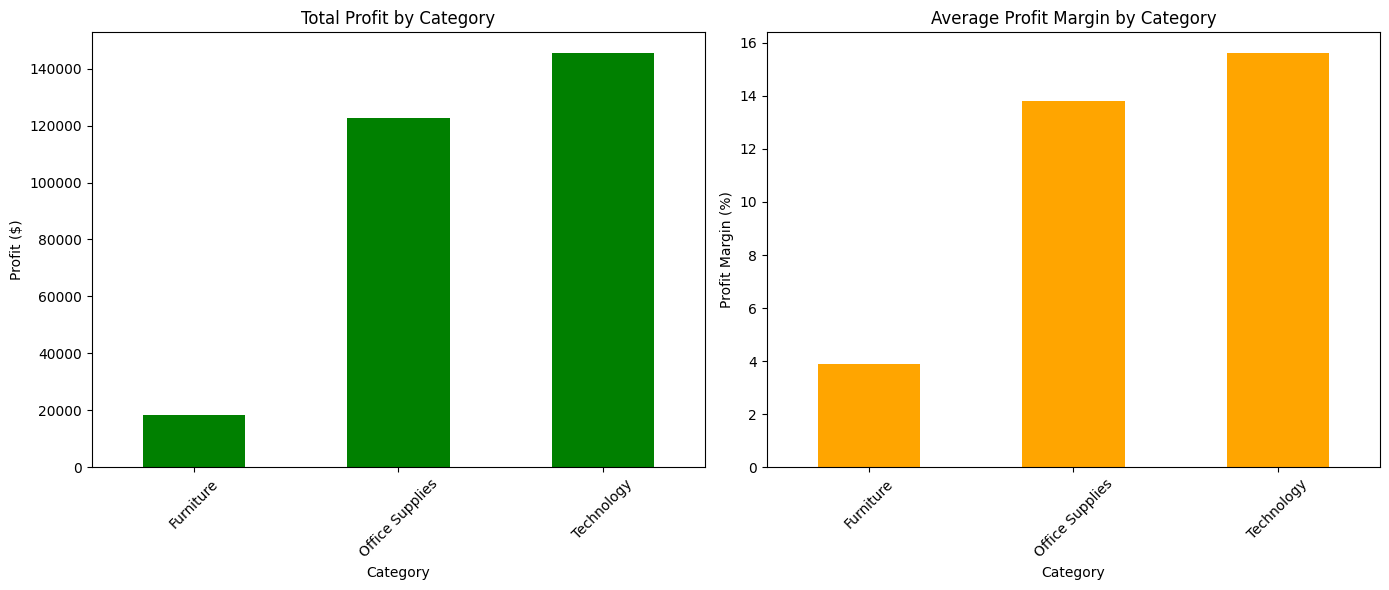

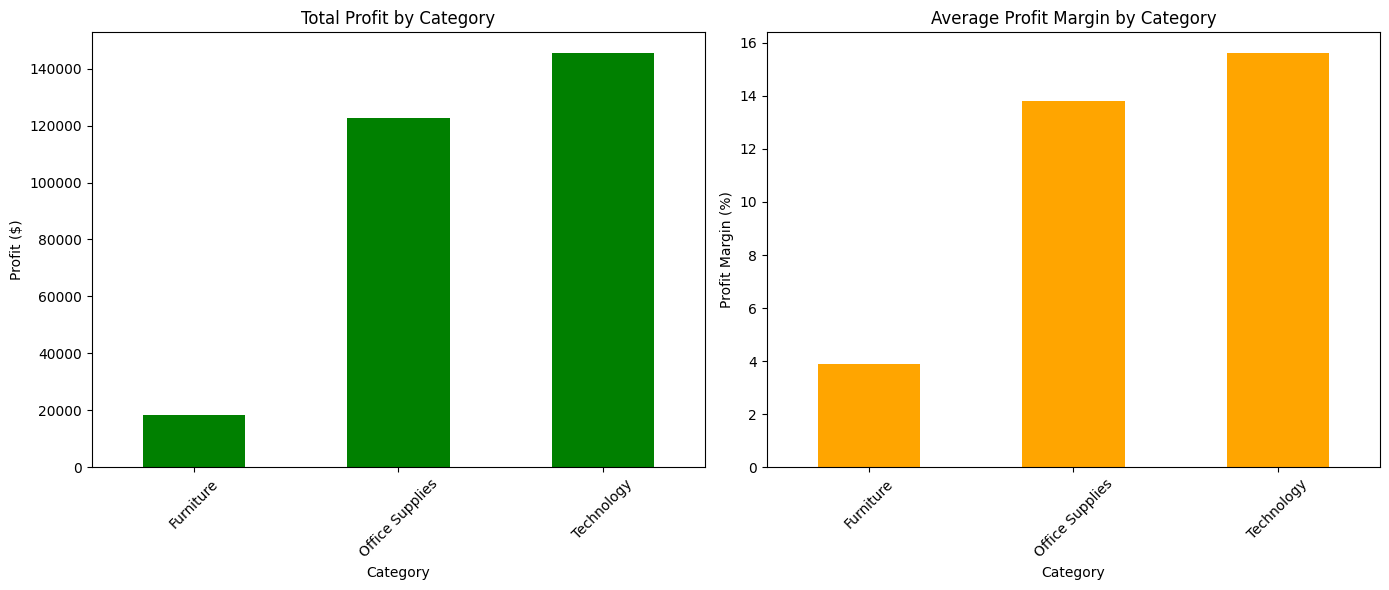

In [13]:
# Visualize profit by category
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

profit_by_category['Profit'].plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Total Profit by Category')
axes[0].set_ylabel('Profit ($)')
axes[0].tick_params(axis='x', rotation=45)

profit_by_category['Profit Margin'].plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Average Profit Margin by Category')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('profit_analysis.png', dpi=300)
plt.show()


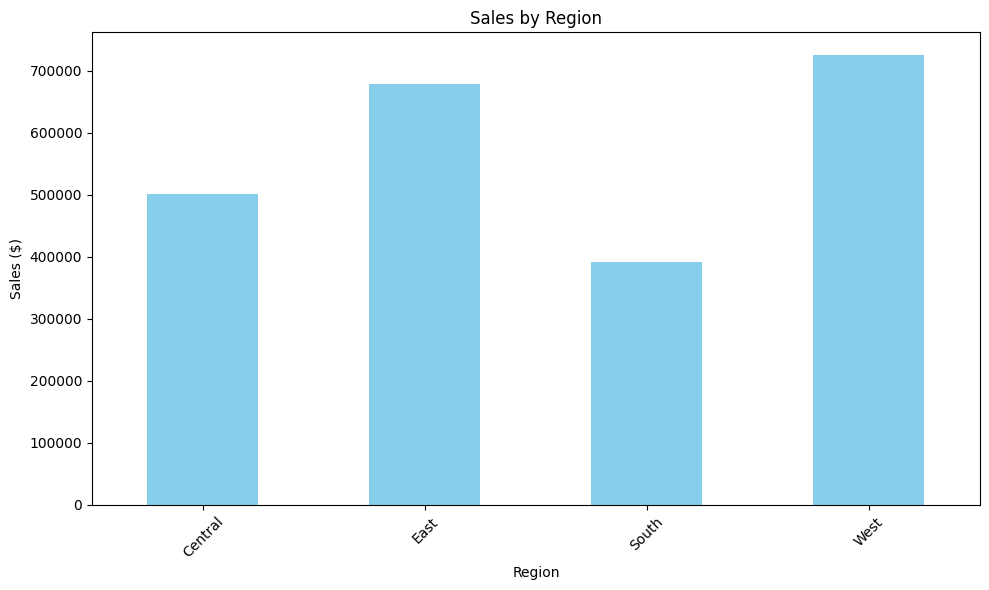

In [14]:
# 4. Regional Performance
regional_performance = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Orders'})

plt.figure(figsize=(10, 6))
regional_performance['Sales'].plot(kind='bar', color='skyblue')
plt.title('Sales by Region')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('regional_sales.png', dpi=300)
plt.show()

In [15]:
# 5. Business Insights Report
insights = f"""
=== BUSINESS INSIGHTS REPORT ===

1. Revenue Performance:
   - Total Revenue: ${df['Sales'].sum():,.2f}
   - Average Order Value: ${df['Sales'].mean():.2f}
   - Best Month: {monthly_revenue.loc[monthly_revenue['Sales'].idxmax(), 'Year-Month']}

2. Product Performance:
   - Top Product: {top_products.index[0]}
   - Top Product Revenue: ${top_products.iloc[0]:,.2f}

3. Profitability:
   - Total Profit: ${df['Profit'].sum():,.2f}
   - Average Profit Margin: {df['Profit Margin'].mean():.2f}%
   - Most Profitable Category: {profit_by_category['Profit'].idxmax()}

4. Regional Insights:
   - Top Region: {regional_performance['Sales'].idxmax()}
   - Region Revenue: ${regional_performance['Sales'].max():,.2f}
"""

print(insights)


=== BUSINESS INSIGHTS REPORT ===

1. Revenue Performance:
   - Total Revenue: $2,297,200.86
   - Average Order Value: $229.86
   - Best Month: 2017-11

2. Product Performance:
   - Top Product: Canon imageCLASS 2200 Advanced Copier
   - Top Product Revenue: $61,599.82

3. Profitability:
   - Total Profit: $286,397.02
   - Average Profit Margin: 12.03%
   - Most Profitable Category: Technology

4. Regional Insights:
   - Top Region: West
   - Region Revenue: $725,457.82



In [16]:
# Save report
with open('business_insights_report.txt', 'w') as f:
    f.write(insights)